In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add src directory to path to import postprocessing functions
sys.path.append(str(Path.cwd()))
import postprocessing_single

def read_observed_streamflow(config_dir, gauge_id, start_date, end_date):
    """Read observed streamflow from Q_daily.rvt file."""
    
    config_dir = Path(config_dir)
    q_file = config_dir / f"catchment_{gauge_id}" / "HBV" / "data_obs" / "Q_daily.rvt"
    
    if not q_file.exists():
        print(f"ERROR: Q_daily.rvt not found at {q_file}")
        return None
    
    print(f"Reading observed streamflow from: {q_file}")
    
    # Read the file
    with open(q_file, 'r') as f:
        lines = f.readlines()
    
    # Find the data start line
    data_start_idx = 0
    for i, line in enumerate(lines):
        if line.strip().startswith(':ObservationData'):
            data_start_idx = i + 1
            break
    
    # Parse the start date from the file
    date_line = lines[data_start_idx].strip().split()
    file_start_date = pd.to_datetime(f"{date_line[0]} {date_line[1]}")
    n_values = int(date_line[2])
    
    # Read all discharge values
    discharge_values = []
    for line in lines[data_start_idx + 1:]:
        line = line.strip()
        if line and not line.startswith(':'):
            try:
                value = float(line)
                discharge_values.append(value)
            except ValueError:
                continue
    
    # Create date range
    dates = pd.date_range(start=file_start_date, periods=len(discharge_values), freq='D')
    
    # Create DataFrame
    df = pd.DataFrame({
        'date': dates,
        'obs_Q': discharge_values
    })
    
    # Replace -1.2345 (missing data flag) with NaN
    df['obs_Q'] = df['obs_Q'].replace(-1.2345, np.nan)
    
    # Filter for requested period
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    
    df = df[(df['date'] >= start_date) & (df['date'] <= end_date)].copy()
    
    print(f"  Filtered to period: {start_date.date()} to {end_date.date()}")
    print(f"  Final data points: {len(df)}")
    print(f"  Valid data points: {df['obs_Q'].notna().sum()}")
    
    return df

def convert_streamflow_to_mm_day(streamflow_m3s, catchment_area_km2):
    """
    Convert streamflow from m³/s to mm/day.
    
    Parameters:
    -----------
    streamflow_m3s : float or array
        Streamflow in m³/s
    catchment_area_km2 : float
        Catchment area in km²
        
    Returns:
    --------
    float or array
        Streamflow in mm/day
    """
    # m³/s to m³/day
    streamflow_m3_day = streamflow_m3s * 86400
    
    # m³/day to mm/day over catchment area
    # 1 m³ = 1000 L = 1000 kg of water
    # Over 1 km² = 1,000,000 m² -> 1 m³ = 1000/1,000,000 = 0.001 mm
    streamflow_mm_day = (streamflow_m3_day / (catchment_area_km2 * 1e6)) * 1000
    
    return streamflow_mm_day

def get_catchment_area(config_dir, gauge_id):
    """Get catchment area from HRU shapefile in topo_files."""
    import geopandas as gpd
    
    config_dir = Path(config_dir)
    
    # Read from HRU shapefile in topo_files
    shapefile = config_dir / f"catchment_{gauge_id}" / "topo_files" / "HRU.shp"
    
    if shapefile.exists():
        gdf = gpd.read_file(shapefile)
        
        # Sort by HRU_ID to ensure correct order
        gdf_sorted = gdf.sort_values('HRU_ID').reset_index(drop=True)
        
        # Use the Area_km2 column directly (already calculated correctly)
        if 'Area_km2' in gdf_sorted.columns:
            area_km2 = gdf_sorted['Area_km2'].sum()
            print(f"  Catchment area from HRU.shp: {area_km2:.2f} km²")
            print(f"  Number of HRUs: {len(gdf_sorted)}")
            return area_km2
        else:
            print(f"  WARNING: 'Area_km2' column not found in HRU.shp")
            print(f"  Available columns: {gdf_sorted.columns.tolist()}")
            
            # Fallback: calculate from geometry (but this might be wrong!)
            gdf_projected = gdf.to_crs('EPSG:3857')  # Web Mercator
            area_m2 = gdf_projected.geometry.area.sum()
            area_km2 = area_m2 / 1e6
            print(f"  WARNING: Using calculated area: {area_km2:.2f} km² (may be incorrect!)")
            return area_km2
    else:
        print(f"  WARNING: Could not find HRU.shp at {shapefile}")
        return None
def read_irrigation_timeseries(config_dir, gauge_id, start_date, end_date):
    """Read irrigation time series using create_irrigation_timeseries function."""
    
    # Create config dictionary for the function
    config = {
        'main_dir': str(Path(config_dir).parent),
        'config_dir': Path(config_dir).name,
        'gauge_id': gauge_id,
        'model_type': 'HBV'
    }
    
    print(f"Reading irrigation time series for catchment {gauge_id}...")
    
    # Use the existing function from postprocessing_single
    irrigation_df = postprocessing_single.create_irrigation_timeseries(config)
    
    if irrigation_df is None:
        print("  No irrigation data available")
        return None
    
    # Filter for requested period
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    
    irrigation_df = irrigation_df[(irrigation_df['date'] >= start_date) & (irrigation_df['date'] <= end_date)].copy()
    
    print(f"  Filtered to period: {start_date.date()} to {end_date.date()}")
    print(f"  Data points: {len(irrigation_df)}")
    
    return irrigation_df

def compare_irrigation_outputs_with_observed(gauge_id, start_date, end_date, 
                                             main_dir='/home/jberg/OneDrive/Raven_worldwide'):
    """
    Compare two irrigation outputs (geodetic mass balance vs snowline) with observed streamflow.
    """
    
    main_dir = Path(main_dir)
    
    # Define the two configuration directories
    config_geodetic = main_dir / '03_model_setups_coupled_geodetic_mass_balance'
    config_snowline = main_dir / '03_model_setups_coupled_snowline'
    
    print(f"\n{'='*80}")
    print(f"COMPARING IRRIGATION OUTPUTS WITH OBSERVED STREAMFLOW")
    print(f"{'='*80}")
    print(f"Catchment: {gauge_id}")
    print(f"Period: {start_date} to {end_date}")
    print(f"Geodetic config: {config_geodetic}")
    print(f"Snowline config: {config_snowline}")
    print(f"{'='*80}\n")
    
    # Get catchment area
    print("0. Getting catchment area...")
    catchment_area_km2 = get_catchment_area(config_geodetic, gauge_id)
    
    if catchment_area_km2 is None:
        print("ERROR: Could not determine catchment area")
        return None
    
    # Read observed streamflow
    print("\n1. Reading observed streamflow...")
    obs_df = read_observed_streamflow(config_geodetic, gauge_id, start_date, end_date)
    
    if obs_df is None:
        print("ERROR: Failed to read observed streamflow")
        return None
    
    # Convert observed streamflow to mm/day
    obs_df['obs_Q_mm_day'] = convert_streamflow_to_mm_day(obs_df['obs_Q'], catchment_area_km2)
    print(f"  Converted streamflow to mm/day (mean: {obs_df['obs_Q_mm_day'].mean():.4f} mm/day)")
    
    # Read irrigation data (GEODETIC)
    print("\n2. Reading irrigation data (Geodetic Mass Balance)...")
    irrigation_geodetic = read_irrigation_timeseries(config_geodetic, gauge_id, start_date, end_date)
    
    # Read irrigation data (SNOWLINE)
    print("\n3. Reading irrigation data (Snowline)...")
    irrigation_snowline = read_irrigation_timeseries(config_snowline, gauge_id, start_date, end_date)
    
    # Calculate monthly regimes
    print("\n4. Calculating monthly regimes...")
    
    # Observed streamflow regime (in mm/day)
    obs_df['month'] = obs_df['date'].dt.month
    obs_regime_mm_day = obs_df.groupby('month')['obs_Q_mm_day'].mean()
    
    # Irrigation regime (geodetic)
    irrigation_geodetic_regime = None
    if irrigation_geodetic is not None:
        irrigation_geodetic['month'] = irrigation_geodetic['date'].dt.month
        irrigation_geodetic_regime = irrigation_geodetic.groupby('month')['irrigation_mm_day'].mean()
    
    # Irrigation regime (snowline)
    irrigation_snowline_regime = None
    if irrigation_snowline is not None:
        irrigation_snowline['month'] = irrigation_snowline['date'].dt.month
        irrigation_snowline_regime = irrigation_snowline.groupby('month')['irrigation_mm_day'].mean()
    
    # Create comparison plots
    print("\n5. Creating comparison plots...")
    
    months = range(1, 13)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Create figure with two panels
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # LEFT PANEL: Geodetic Mass Balance
    # Plot observed streamflow first (as reference)
    ax1.plot(months, obs_regime_mm_day.values, 'k-', linewidth=2.5, 
            marker='o', markersize=8, label='Observed Streamflow', zorder=3)
    
    if irrigation_geodetic_regime is not None:
        ax1.plot(months, irrigation_geodetic_regime.values, 'g-', linewidth=3, 
                marker='s', markersize=8, label='Irrigation (Geodetic)', alpha=0.8, zorder=2)
    
    ax1.set_xlabel('Month', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Discharge (mm/day)', fontsize=14, fontweight='bold')
    ax1.set_title('Geodetic Mass Balance', fontsize=16, fontweight='bold')
    ax1.set_xticks(months)
    ax1.set_xticklabels(month_names, fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7, zorder=0)
    ax1.legend(fontsize=12)
    
    if irrigation_geodetic_regime is not None:
        mean_geodetic = irrigation_geodetic_regime.mean()
        mean_obs = obs_regime_mm_day.mean()
        stats_text = f"Irrigation mean: {mean_geodetic:.4f} mm/day\nStreamflow mean: {mean_obs:.4f} mm/day\nRatio: {mean_geodetic/mean_obs:.2%}"
        ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
                verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9))
    
    # RIGHT PANEL: Snowline
    # Plot observed streamflow first (as reference)
    ax2.plot(months, obs_regime_mm_day.values, 'k-', linewidth=2.5, 
            marker='o', markersize=8, label='Observed Streamflow', zorder=3)
    
    if irrigation_snowline_regime is not None:
        ax2.plot(months, irrigation_snowline_regime.values, 'C3-', linewidth=3, 
                marker='s', markersize=8, label='Irrigation (Snowline)', alpha=0.8, zorder=2)
    
    ax2.set_xlabel('Month', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Discharge (mm/day)', fontsize=14, fontweight='bold')
    ax2.set_title('Snowline', fontsize=16, fontweight='bold')
    ax2.set_xticks(months)
    ax2.set_xticklabels(month_names, fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7, zorder=0)
    ax2.legend(fontsize=12)
    
    if irrigation_snowline_regime is not None:
        mean_snowline = irrigation_snowline_regime.mean()
        mean_obs = obs_regime_mm_day.mean()
        stats_text = f"Irrigation mean: {mean_snowline:.4f} mm/day\nStreamflow mean: {mean_obs:.4f} mm/day\nRatio: {mean_snowline/mean_obs:.2%}"
        ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes,
                verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9))
    
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Print summary
    print(f"\n{'='*80}")
    print(f"COMPARISON SUMMARY")
    print(f"{'='*80}")
    print(f"Catchment: {gauge_id}")
    print(f"Catchment area: {catchment_area_km2:.2f} km²")
    print(f"Period: {start_date} to {end_date}")
    
    print(f"\nObserved Streamflow:")
    print(f"  Mean: {obs_regime_mm_day.mean():.4f} mm/day")
    print(f"  Peak month: {month_names[obs_regime_mm_day.idxmax()-1]}")
    
    if irrigation_geodetic_regime is not None:
        print(f"\nIrrigation (Geodetic Mass Balance):")
        print(f"  Mean: {irrigation_geodetic_regime.mean():.4f} mm/day")
        print(f"  Peak month: {month_names[irrigation_geodetic_regime.idxmax()-1]}")
        print(f"  Ratio to streamflow: {irrigation_geodetic_regime.mean()/obs_regime_mm_day.mean():.2%}")
    
    if irrigation_snowline_regime is not None:
        print(f"\nIrrigation (Snowline):")
        print(f"  Mean: {irrigation_snowline_regime.mean():.4f} mm/day")
        print(f"  Peak month: {month_names[irrigation_snowline_regime.idxmax()-1]}")
        print(f"  Ratio to streamflow: {irrigation_snowline_regime.mean()/obs_regime_mm_day.mean():.2%}")
    
    if irrigation_geodetic_regime is not None and irrigation_snowline_regime is not None:
        diff = irrigation_geodetic_regime.mean() - irrigation_snowline_regime.mean()
        print(f"\nDifference (Geodetic - Snowline):")
        print(f"  {diff:.4f} mm/day ({(diff/irrigation_geodetic_regime.mean()*100):+.1f}%)")
    
    print(f"{'='*80}\n")
    
    # Return all data
    return {
        'observed': obs_df,
        'irrigation_geodetic': irrigation_geodetic,
        'irrigation_snowline': irrigation_snowline,
        'catchment_area_km2': catchment_area_km2,
        'regimes': {
            'observed_mm_day': obs_regime_mm_day,
            'irrigation_geodetic': irrigation_geodetic_regime,
            'irrigation_snowline': irrigation_snowline_regime
        }
    }

# Example usage:
# result = compare_irrigation_outputs_with_observed(
#     gauge_id='0102',
#     start_date='1980-01-01',
#     end_date='2010-12-31'
# )


COMPARING IRRIGATION OUTPUTS WITH OBSERVED STREAMFLOW
Catchment: 0118
Period: 1980-01-01 to 1998-12-31
Geodetic config: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_geodetic_mass_balance
Snowline config: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline

0. Getting catchment area...
  Catchment area from HRU.shp: 6711.46 km²
  Number of HRUs: 998

1. Reading observed streamflow...
Reading observed streamflow from: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_geodetic_mass_balance/catchment_0118/HBV/data_obs/Q_daily.rvt
  Filtered to period: 1980-01-01 to 1998-12-31
  Final data points: 5114
  Valid data points: 4319
  Converted streamflow to mm/day (mean: 2.7608 mm/day)

2. Reading irrigation data (Geodetic Mass Balance)...
Reading irrigation time series for catchment 0118...
Creating irrigation time series for catchment 0118:
  - Irrigation file: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_geodetic_mass_balance/catc

/home/jberg/Raven-world/src/postprocessing_single.py:3075: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  - Dimensions: {list(ds.dims.keys())}")


  - Processed 730/5114 time steps...
  - Processed 1095/5114 time steps...
  - Processed 1460/5114 time steps...
  - Processed 1825/5114 time steps...
  - Processed 2190/5114 time steps...
  - Processed 2555/5114 time steps...
  - Processed 2920/5114 time steps...
  - Processed 3285/5114 time steps...
  - Processed 3650/5114 time steps...
  - Processed 4015/5114 time steps...
  - Processed 4380/5114 time steps...
  - Processed 4745/5114 time steps...
  - Processed 5110/5114 time steps...
  - Created time series with 5114 records
  - Mean irrigation: 1.0265 mm/day
  - Max irrigation: 15.1005 mm/day
  - Min irrigation: 0.0000 mm/day
  - Zero irrigation days: 2643/5114
  ✓ Saved irrigation time series to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_geodetic_mass_balance/catchment_0118/HBV/data_obs/irrigation_timeseries.csv
  Filtered to period: 1980-01-01 to 1998-12-31
  Data points: 5114

3. Reading irrigation data (Snowline)...
Reading irrigation time series for catchme

/home/jberg/Raven-world/src/postprocessing_single.py:3075: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  - Dimensions: {list(ds.dims.keys())}")


  - Processed 365/5114 time steps...
  - Processed 730/5114 time steps...
  - Processed 1095/5114 time steps...
  - Processed 1460/5114 time steps...
  - Processed 1825/5114 time steps...
  - Processed 2190/5114 time steps...
  - Processed 2555/5114 time steps...
  - Processed 2920/5114 time steps...
  - Processed 3285/5114 time steps...
  - Processed 3650/5114 time steps...
  - Processed 4015/5114 time steps...
  - Processed 4380/5114 time steps...
  - Processed 4745/5114 time steps...
  - Processed 5110/5114 time steps...
  - Created time series with 5114 records
  - Mean irrigation: 4.0332 mm/day
  - Max irrigation: 68.8428 mm/day
  - Min irrigation: 0.0000 mm/day
  - Zero irrigation days: 1548/5114
  ✓ Saved irrigation time series to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled_snowline/catchment_0118/HBV/data_obs/irrigation_timeseries.csv
  Filtered to period: 1980-01-01 to 1998-12-31
  Data points: 5114

4. Calculating monthly regimes...

5. Creating comparison p

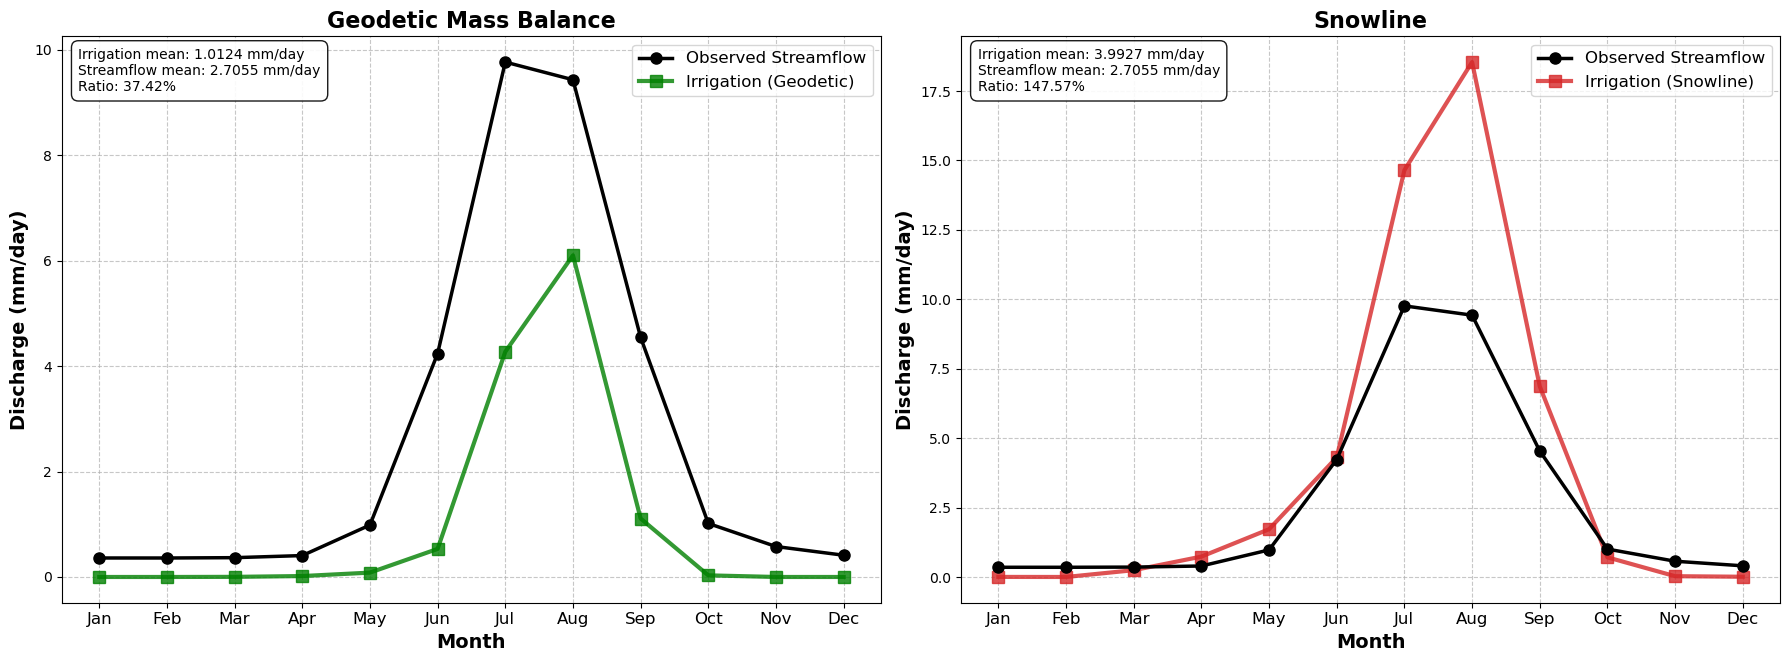


COMPARISON SUMMARY
Catchment: 0118
Catchment area: 6711.46 km²
Period: 1980-01-01 to 1998-12-31

Observed Streamflow:
  Mean: 2.7055 mm/day
  Peak month: Jul

Irrigation (Geodetic Mass Balance):
  Mean: 1.0124 mm/day
  Peak month: Aug
  Ratio to streamflow: 37.42%

Irrigation (Snowline):
  Mean: 3.9927 mm/day
  Peak month: Aug
  Ratio to streamflow: 147.57%

Difference (Geodetic - Snowline):
  -2.9803 mm/day (-294.4%)



In [2]:
# Example usage:
result = compare_irrigation_outputs_with_observed(
     gauge_id='0118',
     start_date='1980-01-01',
     end_date='1998-12-31'
)